In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
df = pd.read_csv(r"C:\Users\Sufiyan\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Step 1 : Remove Unneccesary Feature 
* 1. Found customerID column that didn't make any impact 

In [4]:
df.drop(columns=["customerID"], inplace=True)

In [5]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Step 2 : Identify and Remove/Handle Duplicates and Null Values 

* 1. Found 22 Rows Duplicated

In [6]:
df[df.duplicated()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
964,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.7,Yes
1338,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes
1491,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
1739,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.90,69.9,Yes
1932,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.20,20.2,No
2713,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.45,20.45,No
2892,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.45,20.45,No
3301,Female,1,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.60,69.6,Yes
3754,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,20.05,No
4098,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.20,20.2,Yes


In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df[df.duplicated()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


# Step 3 : Handle Missing Values

* 1. Found TotalCharges have multiple " " empty space values 

In [9]:
df['TotalCharges'].value_counts()

TotalCharges
          11
19.75      9
20.2       8
19.65      7
19.9       7
          ..
1990.5     1
7362.9     1
346.45     1
306.6      1
108.15     1
Name: count, Length: 6531, dtype: int64

In [10]:
for col in df.columns:
    print(f"Name : {col}\n")
    print(df[df[col] == " "])
    print("-"*50)

Name : gender

Empty DataFrame
Columns: [gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn]
Index: []
--------------------------------------------------
Name : SeniorCitizen

Empty DataFrame
Columns: [gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn]
Index: []
--------------------------------------------------
Name : Partner

Empty DataFrame
Columns: [gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessB

In [11]:
df["TotalCharges"].replace({" " : "0"},inplace=True)

C:\Users\Sufiyan\AppData\Local\Temp\ipykernel_13388\1031550559.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].replace({" " : "0"},inplace=True)


In [12]:
df[df['TotalCharges'] == "0"]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,0,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,0,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,0,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,0,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,0,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,0,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,0,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,0,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,0,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,0,No


# Step 4 :  Print unique values in all columns (spot typos/inconsistent categories)

* 1. Identified that TotalCharges has an incorrect data type.

In [13]:
# Categorical Feature
for col_name in df.select_dtypes("object"):
    print(f"Name : {col_name}")
    print(f"Unique Values - {df[col_name].unique()}")
    print("-"*50)

Name : gender
Unique Values - ['Female' 'Male']
--------------------------------------------------
Name : Partner
Unique Values - ['Yes' 'No']
--------------------------------------------------
Name : Dependents
Unique Values - ['No' 'Yes']
--------------------------------------------------
Name : PhoneService
Unique Values - ['No' 'Yes']
--------------------------------------------------
Name : MultipleLines
Unique Values - ['No phone service' 'No' 'Yes']
--------------------------------------------------
Name : InternetService
Unique Values - ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
Name : OnlineSecurity
Unique Values - ['No' 'Yes' 'No internet service']
--------------------------------------------------
Name : OnlineBackup
Unique Values - ['Yes' 'No' 'No internet service']
--------------------------------------------------
Name : DeviceProtection
Unique Values - ['No' 'Yes' 'No internet service']
--------------------------------------------------

In [14]:
# Numerical Feature
for col_name in df.select_dtypes("number"):
    print(f"Name : {col_name}")
    print(f"Unique Values - {df[col_name].unique()}")
    print("-"*50)

Name : SeniorCitizen
Unique Values - [0 1]
--------------------------------------------------
Name : tenure
Unique Values - [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
--------------------------------------------------
Name : MonthlyCharges
Unique Values - [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
--------------------------------------------------


# Step 5 : Fix Data Type

* 1. Found on Step 4 that TotalCharges is Object data type

In [15]:
df["TotalCharges"] = df['TotalCharges'].astype(float)

# Step 6 : Check Class Imbalance in Target Column (Churn)

* 1. Found Imbalance data in Churn No/Yes .73 / .26

In [16]:
df["Churn"].value_counts()/len(df['Churn']) * 100

Churn
No     73.550776
Yes    26.449224
Name: count, dtype: float64

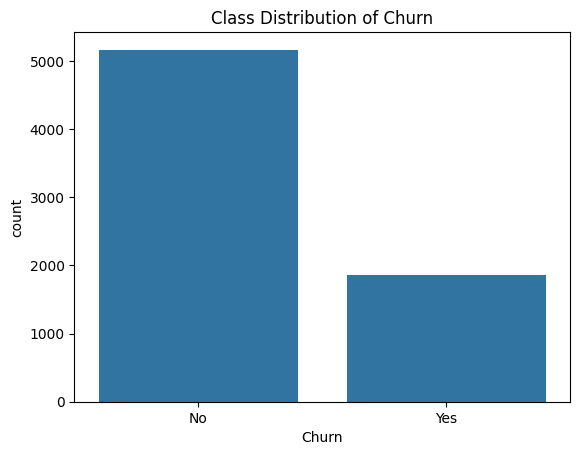

In [17]:
sb.countplot(data=df, x="Churn")
plt.title("Class Distribution of Churn")
plt.show()

# Step 7 : Distribution of Numerical Feature (Histogram and KDE)

In [18]:
def plot_histogram(df, col_name):
    plt.figure(figsize=(8,6))
    sb.histplot(df[col_name], kde=True)
    plt.title(f"Distribution of {col_name}")
    plt.show()

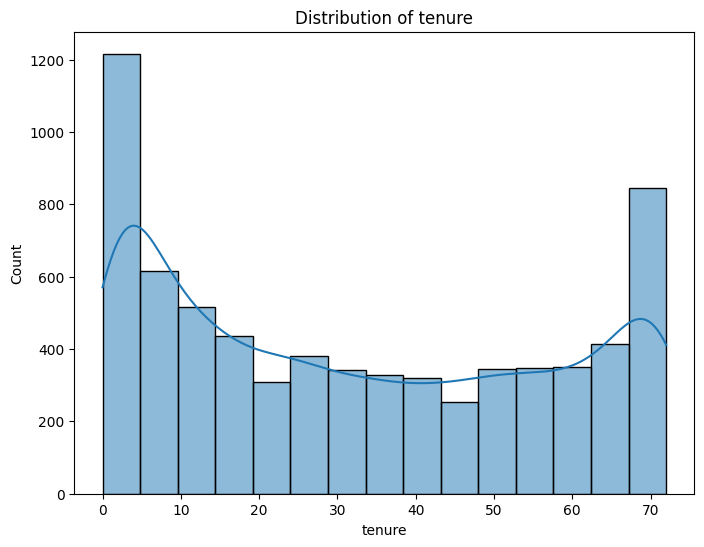

In [19]:
plot_histogram(df, "tenure")

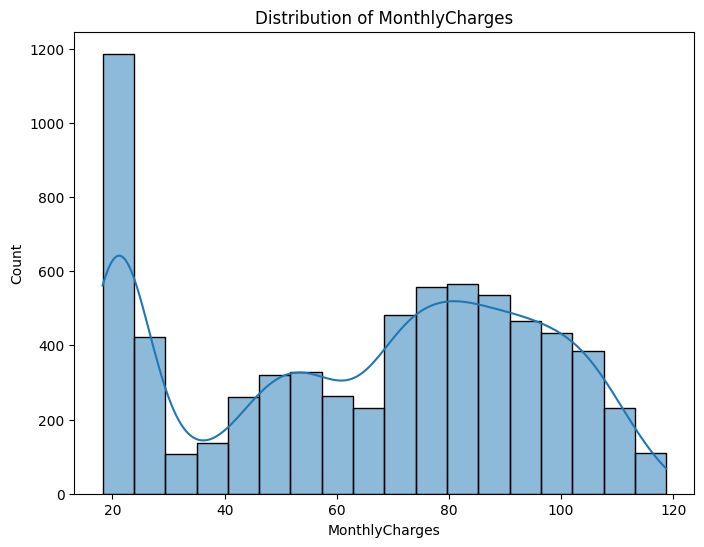

In [20]:
plot_histogram(df, "MonthlyCharges")

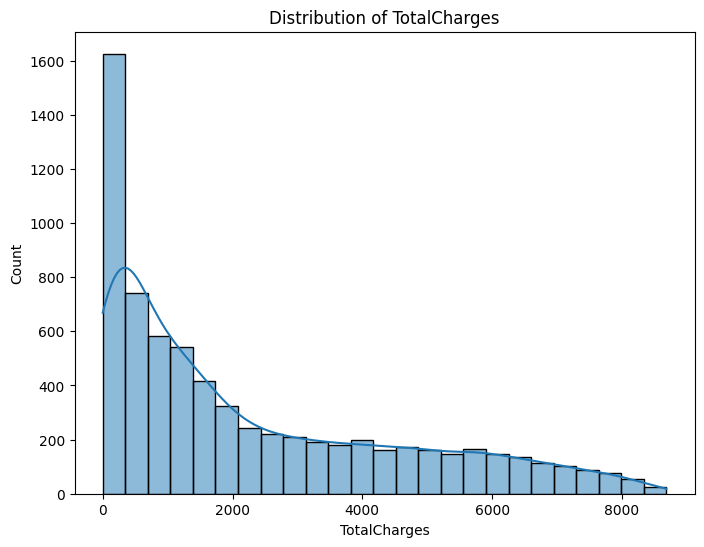

In [21]:
plot_histogram(df, "TotalCharges")

# Distribution Analysis of Numerical Features

* 1. Tenure Feature

    * Not normally distributed.
    * Bimodal/U-shaped distribution with peaks at both ends.
    * Highest concentration between 0–5 months.
    * Second peak around 65–72 months.
    * Lower frequency in the middle tenure range (20–50 months).
    * No obvious outliers, as tenure is naturally bounded between 0 and 72 months.

* 2. MonthlyCharges Feature

    * The distribution is not normally distributed.
    * Multiple peaks (multimodal) indicate distinct pricing segments.
    * Highest concentration around $20–30.
    * Another major concentration between $70–100.
    * Fewer customers have monthly charges between $30–70.
    * No obvious outliers, as the values fall within the expected pricing range (approximately $18–120).

* 3. TotalCharges Feature

    * The distribution is highly right-skewed (positively skewed).
    * Most customers have low total charges (approximately $0–$1,000).
    * The frequency decreases steadily as total charges increase.
    * A long right tail extends up to around $9,000.
    * No distinct secondary peaks, indicating a single dominant distribution.
    * No obvious outliers, as higher values are expected for long-term customers with higher monthly charges.

# Step 8 : Box plots for numerical features — check outliers

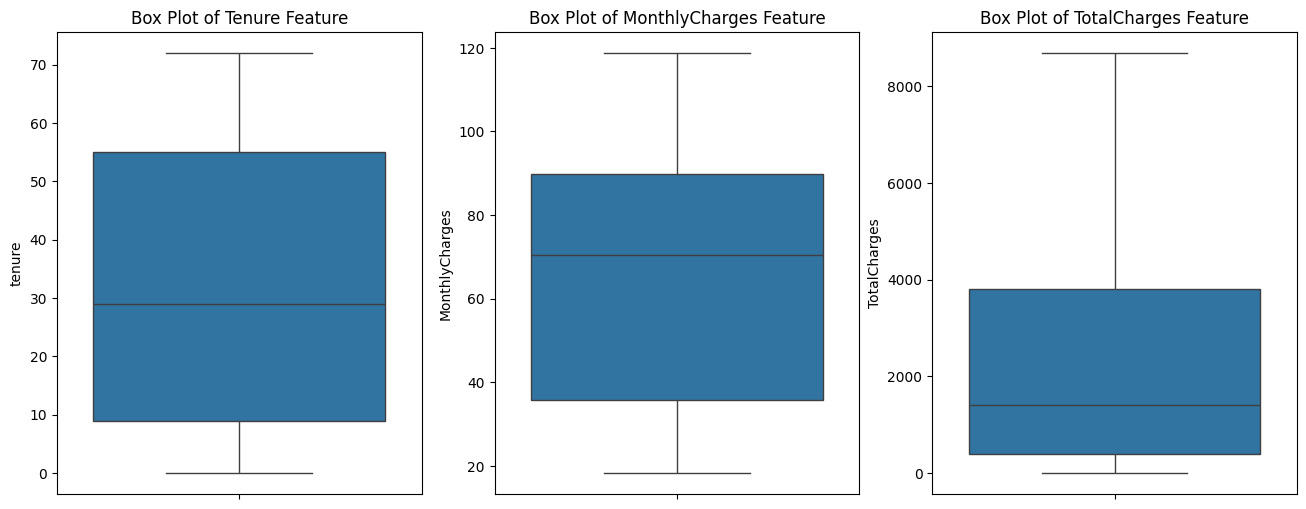

In [22]:
plt.figure(figsize=(16, 6))

plt.subplot(1,3,1)
sb.boxplot(data=df['tenure'])
plt.title("Box Plot of Tenure Feature")

plt.subplot(1,3,2)
sb.boxplot(data=df['MonthlyCharges'])
plt.title("Box Plot of MonthlyCharges Feature")

plt.subplot(1,3,3)
sb.boxplot(data=df['TotalCharges'])
plt.title("Box Plot of TotalCharges Feature")
plt.show()

# Conclusion 

* No significant outliers were detected in the numerical features based on the box plot analysis.

# Step 9 : Correlation heatmap for numerical features

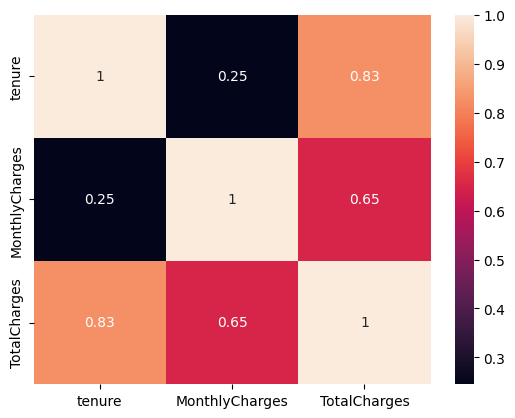

In [23]:
sb.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(), annot=True,)
plt.show()

# Conclusion

* TotalCharges is strongly influenced by customer tenure and moderately influenced by monthly charges, while tenure and monthly charges have only a weak relationship.

# step 10 : Count plots for categorical features

Ratio of gender
Male      50.434411
Female    49.565589
Name: count, dtype: float64


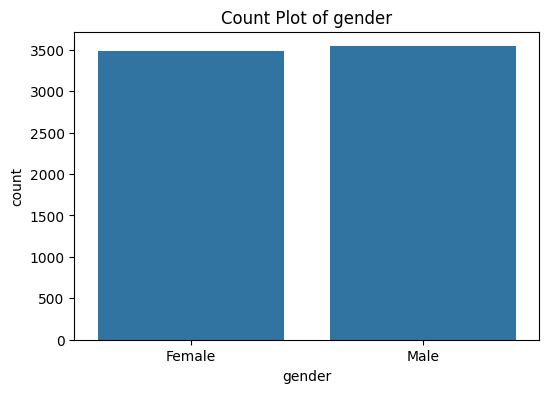

Ratio of Partner
No     51.545364
Yes    48.454636
Name: count, dtype: float64


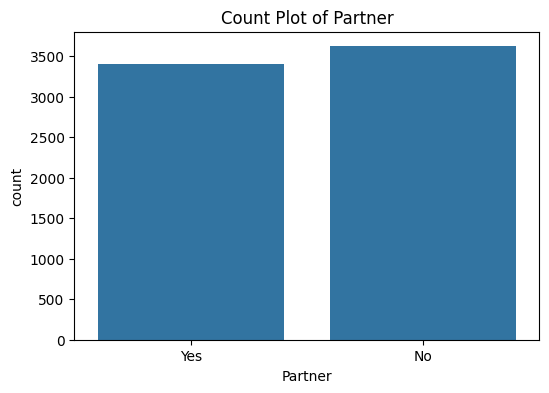

Ratio of Dependents
No     69.947301
Yes    30.052699
Name: count, dtype: float64


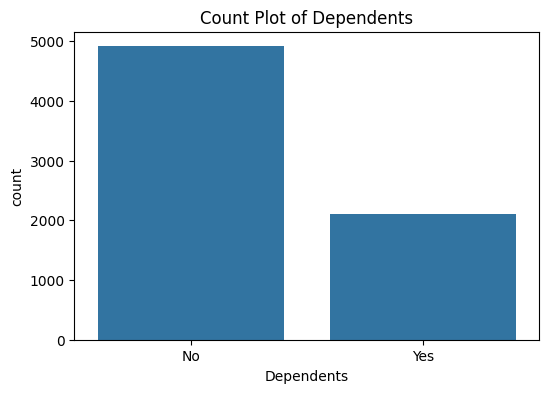

Ratio of PhoneService
Yes    90.286284
No      9.713716
Name: count, dtype: float64


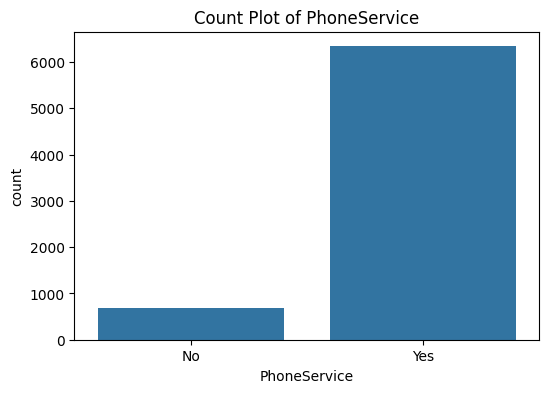

Ratio of MultipleLines
No                  47.970375
Yes                 42.315909
No phone service     9.713716
Name: count, dtype: float64


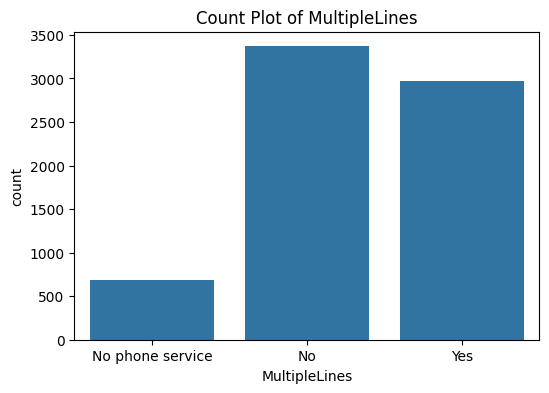

Ratio of InternetService
Fiber optic    44.010825
DSL            34.453782
No             21.535394
Name: count, dtype: float64


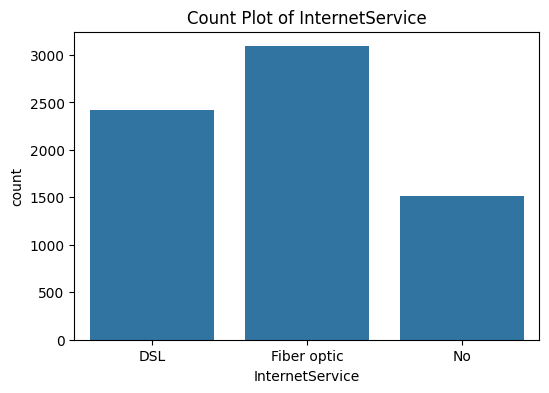

Ratio of OnlineSecurity
No                     49.708019
Yes                    28.756587
No internet service    21.535394
Name: count, dtype: float64


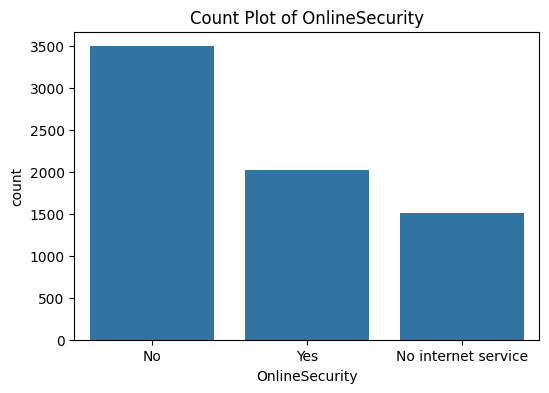

Ratio of OnlineBackup
No                     43.868395
Yes                    34.596211
No internet service    21.535394
Name: count, dtype: float64


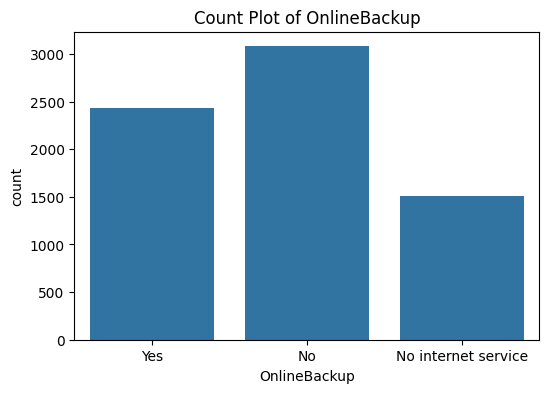

Ratio of DeviceProtection
No                     43.968096
Yes                    34.496510
No internet service    21.535394
Name: count, dtype: float64


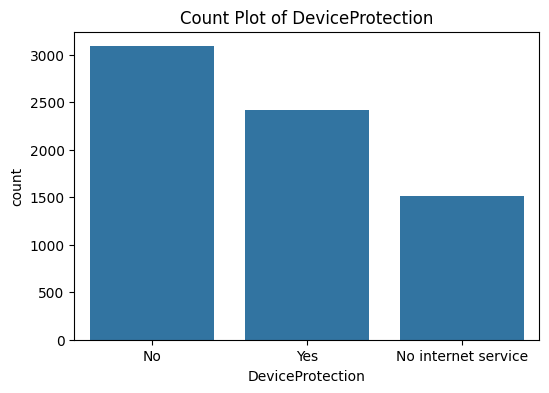

Ratio of TechSupport
No                     49.351944
Yes                    29.112662
No internet service    21.535394
Name: count, dtype: float64


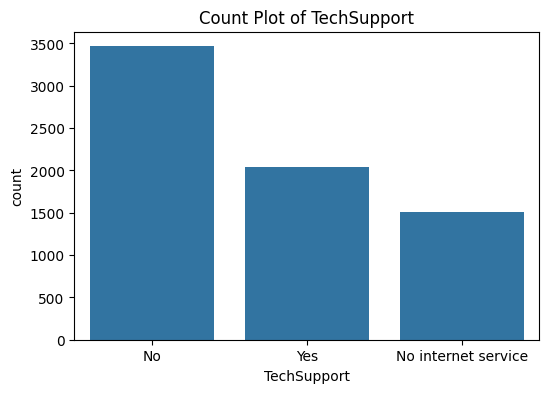

Ratio of StreamingTV
No                     39.908845
Yes                    38.555761
No internet service    21.535394
Name: count, dtype: float64


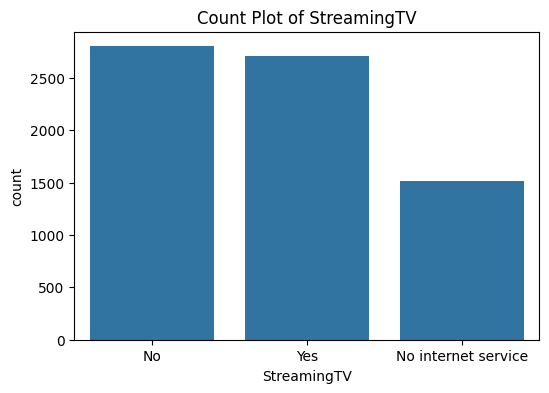

Ratio of StreamingMovies
No                     39.552770
Yes                    38.911836
No internet service    21.535394
Name: count, dtype: float64


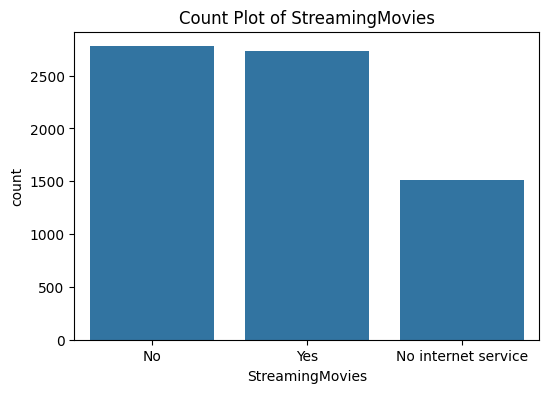

Ratio of Contract
Month-to-month    54.878222
Two year          24.141860
One year          20.979917
Name: count, dtype: float64


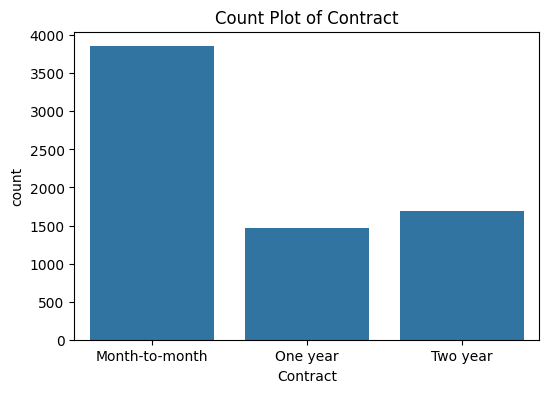

Ratio of PaperlessBilling
Yes    59.265062
No     40.734938
Name: count, dtype: float64


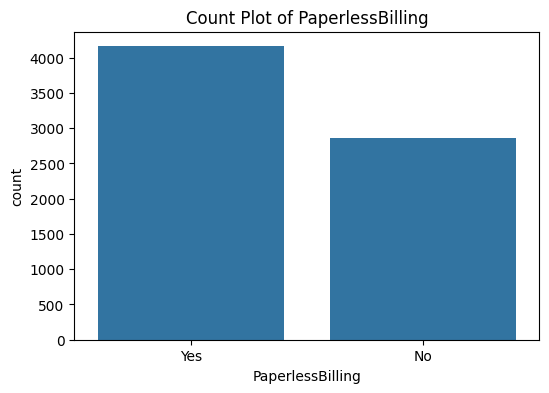

Ratio of PaymentMethod
Electronic check             33.599202
Mailed check                 22.731805
Bank transfer (automatic)    21.991169
Credit card (automatic)      21.677824
Name: count, dtype: float64


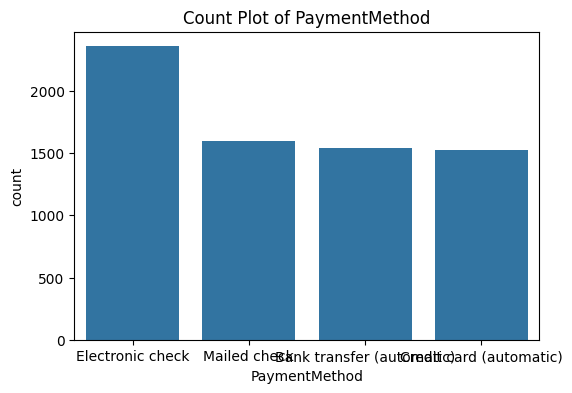

Ratio of Churn
No     73.550776
Yes    26.449224
Name: count, dtype: float64


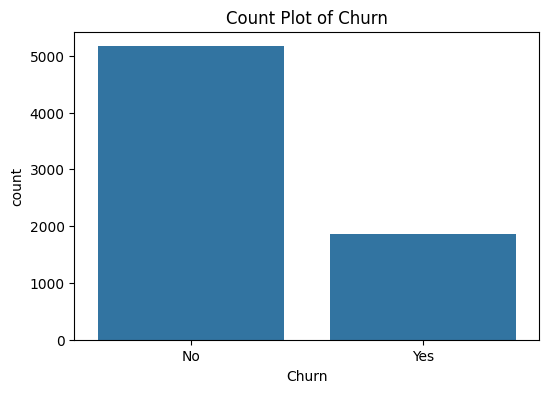

In [27]:
for col in df.select_dtypes("object"):
    plt.figure(figsize=(6,4))
    print(f"Ratio of {df[col].value_counts()/len(df[col]) * 100}")
    sb.countplot(data=df, x=f"{col}")
    plt.title(f"Count Plot of {col}")
    plt.show()

# Conclusion

* Approximately 45% of the categorical features have a nearly balanced distribution across categories, while the remaining 55% exhibit a majority-minority distribution with one category dominating the others

# Step 11 : Create new features — e.g., tenure groups/bins, LongTermCustomer, count of subscribed add-on services

In [36]:
df["TenureGroup"] = pd.cut(df["tenure"], bins=[0, 12, 24, 48, 60, 72], labels=["0-1 Year", "1-2 Years", "2-4 Years",  "4-5 Years","5-6 Years"], include_lowest=True)

In [37]:
df["TenureGroup"].value_counts()

TenureGroup
0-1 Year     2164
2-4 Years    1594
5-6 Years    1407
1-2 Years    1024
4-5 Years     832
Name: count, dtype: int64

<Axes: xlabel='TenureGroup', ylabel='count'>

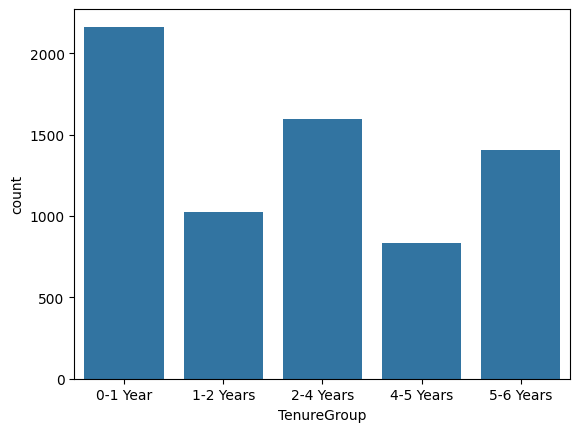

In [38]:
sb.countplot(data=df, x="TenureGroup")

In [40]:
service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]
df["NumAddOnServices"] = (df[service_cols] == "Yes").sum(axis=1)

In [41]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,NumAddOnServices
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-1 Year,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,No,2-4 Years,2
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-1 Year,2
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,2-4 Years,3
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-1 Year,0


In [47]:
df["LongTermCustomer"] = df["tenure"].apply(lambda x: "Yes" if x > 24 else "No")

In [48]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,NumAddOnServices,LongTermCustomer
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-1 Year,1,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,No,2-4 Years,2,Yes
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-1 Year,2,No
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,2-4 Years,3,Yes
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-1 Year,0,No


# Conclusion

* Three new features were created to enrich the dataset: TenureGroup, NumAddOnServices, and LongTermCustomer, capturing customer tenure and service engagement.

# Step 12 : Encode Target Variable (Churn)

In [51]:
le = LabelEncoder()

In [52]:
df["Churn"] = le.fit_transform(df["Churn"])

# Step 13 : Apply One Hot Encoding (only for those rows has more than 3 values) 

In [84]:
binary_cols = ["gender", "Partner" , "Dependents", "PhoneService", "PaperlessBilling", "LongTermCustomer"]

for col in binary_cols:
    df[col].replace({"Yes" : 1, "No" : 0, "Male" : 0 , "Female" : 1},inplace=True)

C:\Users\Sufiyan\AppData\Local\Temp\ipykernel_13388\1122520887.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col].replace({"Yes" : 1, "No" : 0, "Male" : 0 , "Female" : 1},inplace=True)
C:\Users\Sufiyan\AppData\Local\Temp\ipykernel_13388\1122520887.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original obj

In [88]:
one_hot_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod",
    "TenureGroup"
]

ohe = OneHotEncoder(drop="first", sparse_output=False,handle_unknown="ignore")
encode = ohe.fit_transform(df[one_hot_cols])

encode_df = pd.DataFrame(encode, columns=ohe.get_feature_names_out(one_hot_cols), index=df.index)

In [90]:
df = pd.concat([df.drop(columns=one_hot_cols), encode_df],axis=1)

In [93]:
import pickle

In [94]:
ohe

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'first'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_c

In [95]:
with open("one_hot_encoder.pkl","wb") as f:
    pickle.dump(ohe, f)

# Conclusion

* Applied One-Hot Encoding to multi-category features and saved the fitted encoder as a pickle file for consistent future transformations.